In [1]:
import numpy as np
import pandas as pd
import pickle
import math
from matplotlib import pyplot as plt

In [2]:
with open('z_grid0.pkl','rb') as file:
    data = pickle.load(file)
    z_grid = data['z_grid']

print(z_grid.shape)

(98, 98)


In [40]:
# EVA parameters
angles_deg0 = list(range(0, 180, 30))  # [0, 30, 60, 90, 120, 150]
scales0 = list(range(1,6)) # [1, 2, 3, 4, 5]
vc2 = 1.0 # prototype against div by zero

# work on full z_grid (98x98) but
# compute anisotropy only on interior
# points at least max(scales) away from border

s_max0 = max(scales0)
nrows0, ncols0 = z_grid.shape

def func_var_t(z, i, j, t, phi_deg):
    """single scale z-variance between (i,j) and 
        the pixel at distance s in direction phi."""
    phi_rad = math.radians(phi_deg)
    di = int(round(t * math.sin(phi_rad))) # i is vertical in numpy array space
    dj = int(round(t * math.cos(phi_rad))) # j is horizontal in numpy array
    i2 = i + di
    j2 = j + dj
    # if out of bounds return 0
    if i2 < 0 or i2 >= z.shape[0] or j2 < 0 or j2 >= z.shape[0]:
        return 0.0
    return float((z[i,j] - z[i2, j2]) ** 2)

def func_var_s(z, i, j, s, phi_deg):
    """cumulative avg variance up to separation distance s,
        averaging both forward and symmetrically backward"""
    accumulator = 0.0
    for t in range(1, s+1):
        v_fwd = func_var_t(z, i, j, t, phi_deg)
        v_bwd = func_var_t(z, i, j, t, phi_deg + 180)
        accumulator += (v_fwd + v_bwd)
    return accumulator / (2 * s)

In [41]:
# output arrays
anis_mag0 = np.zeros((nrows0, ncols0, len(scales0)))
anis_phi0 = np.zeros((nrows0, ncols0, len(scales0))) + 360

# only compute for interior points at least s_max from border
for i in range(s_max0, nrows0-s_max0):
    for j in range(s_max0, ncols0-s_max0):
        for s_idx0, s0 in enumerate(scales0):

            # compute cumulative averaged variance for each angle
            raw_anis0 = {}
            for phi in angles_deg0:
                raw_anis0[phi] = func_var_s(z_grid, i, j, s0, phi)

            # find angle of minimum variance
            phi_min0 = min(raw_anis0, key=raw_anis0.get)

            # orthogonal angle
            phi_orth0 = (phi_min0 + 90) % 180 # because assuming symmetry

            # anisotropy magnitude per Roy (2015) eq. 5.4
            anis_mag0[i,j,s_idx0] = (vc2 + raw_anis0[phi_orth0]) / (vc2 + raw_anis0[phi_min0])
            anis_phi0[i,j,s_idx0] = phi_min0

print('anis calc\'ed')

anis calc'ed


In [42]:
print(np.count_nonzero(anis_mag0 != 0))
print(np.count_nonzero(anis_phi0 != 360))

38720
38720


In [43]:
np.unique(anis_phi0, return_counts=True)

(array([  0.,  30.,  60.,  90., 120., 150., 360.]),
 array([13192,  5909,  3540,  3859,  4112,  8108,  9300]))

In [44]:
print(anis_phi0.shape)

(98, 98, 5)


In [45]:
print((98-2*s_max0)*(98-2*s_max0)*5) # padding on both sides

38720


# count points where phi_min is genuinely 0
zero_phi = (anis_phi0 == 0).sum()
print("points with phi_min = 0:", zero_phi)

# cross check
nonzero_mag = (anis_mag != 0).sum()
non360_phi = (anis_phi != 360).sum()
print("nonzero anis_mag:", nonzero_mag)
print("non-360 anis_phi:", non360_phi)
print("expected interior points x scales:", (98 - 2*s_max)**2 * len(scales))
print("zero_phi + non360_phi:", zero_phi + non360_phi)

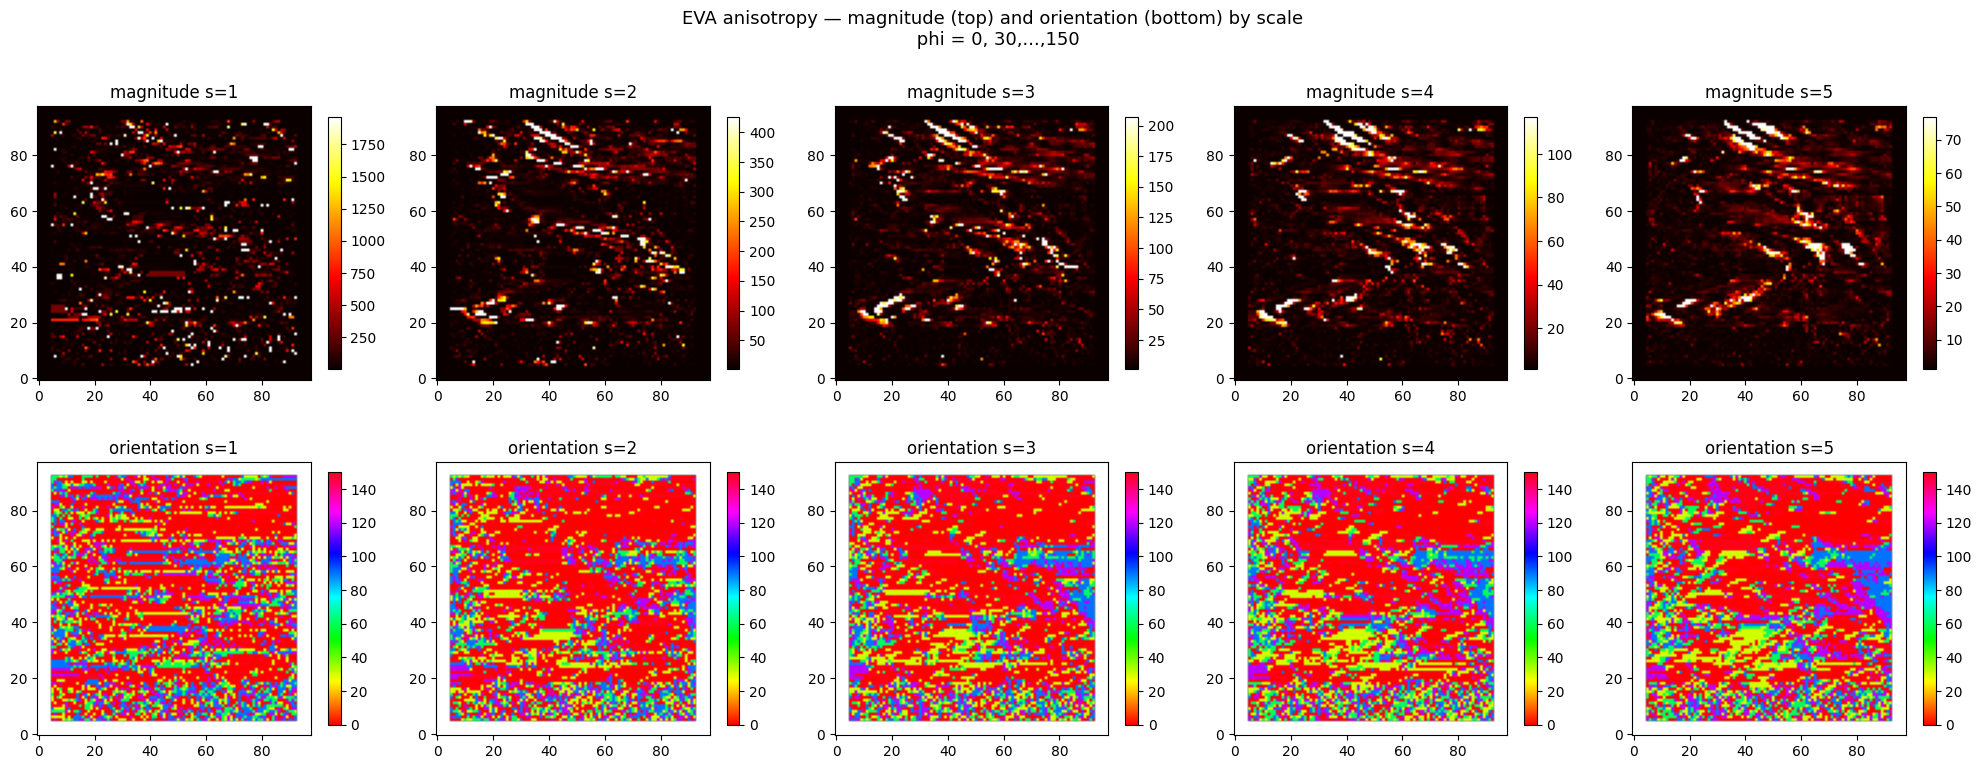

In [46]:
fig, axes = plt.subplots(2, 5, figsize=(20, 8))

for s_idx0, s0 in enumerate(scales0):
    # anisotropy magnitude
    arr_mag0 = anis_mag0[:, :, s_idx0]
    vmin, vmax = np.nanpercentile(arr_mag0[arr_mag0 != 0], [2, 98])
    im = axes[0, s_idx0].imshow(arr_mag0, cmap='hot', origin='lower',
                                vmin=vmin, vmax=vmax)
    plt.colorbar(im, ax=axes[0, s_idx0], shrink=0.7)
    axes[0, s_idx0].set_title(f'magnitude s={s0}')

    # anisotropy orientation
    arr_phi0 = anis_phi0[:, :, s_idx0].copy()
    arr_phi0[arr_phi0 == 360] = np.nan  # mask uncomputed points
    im = axes[1, s_idx0].imshow(arr_phi0, cmap='hsv', origin='lower',
                                vmin=0, vmax=150)
    plt.colorbar(im, ax=axes[1, s_idx0], shrink=0.7)
    axes[1, s_idx0].set_title(f'orientation s={s0}')

plt.suptitle('EVA anisotropy — magnitude (top) and orientation (bottom) by scale \n phi = 0, 30,...,150', fontsize=13)
plt.tight_layout()
#plt.savefig('anis_phi30s5.png')
plt.show()

In [47]:
# vectorized version

import numpy as np

# new EVA parameters
angles_deg = list(range(0, 180, 30))  # first test by comparing [0, 30, ..., 150]
angle_size = 180 // len(angles_deg)
scales = list(range(1,6)) # first test [1, 2, ..., 5]
s_max = max(scales)
nrows, ncols = z_grid.shape
vc2 = 1.0 # prototype against div by zero

# interior slice bounds
pad = s_max
z_interior = z_grid[pad: -pad, pad:-pad] # (88, 88)
n_angles = len(angles_deg)
n_scales = len(scales)
h, w = z_interior.shape

# accumulate variance: shape (h, w, n_angles, n_scales)
var_accum = np.zeros((h, w, n_angles, n_scales))

for a_idx, phi, in enumerate(angles_deg):
    phi_rad = np.radians(phi)
    
    for s_idx, s in enumerate(scales):
        accum = np.zeros((h,w))

        for t in range(1, s+1):

            # forward and backward shifts
            di = int(round(t * math.sin(phi_rad))) # i is vertical in numpy array space
            dj = int(round(t * math.cos(phi_rad))) # j is horizontal in numpy array
        
            # forward variance
            z_shift_fwd = z_grid[pad+di:nrows-pad+di, pad+dj:ncols-pad+dj]
            v_fwd = (z_interior - z_shift_fwd) ** 2
        
            # backward variance (+180 sets di to -di, dj to -dj)
            z_shift_bwd = z_grid[pad-di: nrows-pad-di, pad-dj:ncols-pad-dj]
            v_bwd = (z_interior - z_shift_bwd) ** 2

            accum += v_fwd + v_bwd

        var_accum[:, :, a_idx, s_idx] = accum / (2 * s)

# output arrays
anis_mag = np.zeros((h, w, n_scales))
anis_phi = np.zeros((h, w, n_scales)) + 360 
# 360 indicates where phi_min has/not been assigned

# compute anisotropy magnitude and orientation 
# at each separation distance s
for s_idx in range(n_scales):
    
    # clip the accumulated variances for that s only
    v_s = var_accum[:,:,:,s_idx] # (h,w,n_angles)

    # at each point, retrieve index of minimum variance angle 
    # returns array shape (h,w) -- argmin taken along phi axis
    phi_min_idx = np.argmin(v_s, axis=2)

    # increment phi_min indices to correspond to a 90-degree rotation
    # reflected back from 180-symmetry
    phi_orth_idx = (phi_min_idx + (90//angle_size)) % n_angles

    # gather min and orthogonal variance values
    ii, jj = np.meshgrid(np.arange(h), np.arange(w), indexing='ij')
    v_min = v_s[ii, jj, phi_min_idx]
    v_orth = v_s[ii, jj, phi_orth_idx]

    anis_mag[:, :, s_idx] = (vc2 + v_orth) / (vc2 + v_min)
    anis_phi[:, :, s_idx] = np.array(angles_deg)[phi_min_idx]

print('done')
print("anis_mag shape:", anis_mag.shape)
print("anis_phi shape:", anis_phi.shape)
print("anis_mag range:", np.nanmin(anis_mag).round(3), np.nanmax(anis_mag).round(3))

done
anis_mag shape: (88, 88, 5)
anis_phi shape: (88, 88, 5)
anis_mag range: 1.0 670792.871


# vectorized version

import numpy as np

# new EVA parameters
angles_deg = list(range(0, 180, 30))  # first test by comparing [0, 30, ..., 150]
angle_size = 180 // len(angles_deg)
scales = list(range(1,6)) # first test [1, 2, ..., 5]
s_max = max(scales)
nrows, ncols = z_grid.shape
vc2 = 1.0 # prototype against div by zero

# interior slice bounds
pad = s_max
z_interior = z_grid[pad: -pad, pad:-pad] # (88, 88)
n_angles = len(angles_deg)
n_scales = len(scales)
h, w = z_interior.shape

# accumulate variance: shape (h, w, n_angles, n_scales)
var_accum = np.zeros((h, w, n_angles, n_scales))

for a_idx, phi, in enumerate(angles_deg):
    phi_rad = np.radians(phi)
    
    for s_idx, s in enumerate(scales):

        # forward and backward shifts
        di = int(round(s * math.sin(phi_rad))) # i is vertical in numpy array space
        dj = int(round(s * math.cos(phi_rad))) # j is horizontal in numpy array
    
        # forward variance
        z_shift_fwd = z_grid[pad+di:nrows-pad+di, pad+dj:ncols-pad+dj]
        v_fwd = (z_interior - z_shift_fwd) ** 2
    
        # backward variance (+180 sets di to -di, dj to -dj)
        z_shift_bwd = z_grid[pad-di: nrows-pad-di, pad-dj:ncols-pad-dj]
        v_bwd = (z_interior - z_shift_bwd) ** 2
    
        # cumulative average up to scale s per eqn 5.3
        if s_idx == 0:
            var_accum[:, :, a_idx, s_idx] = (v_fwd + v_bwd) / 2.0
        else:
            prev = var_accum[:, :, a_idx, s_idx - 1]
            var_accum[:, :, a_idx, s_idx] = (prev*(s-1) + (v_fwd+v_bwd)/2) / s

# output arrays
anis_mag = np.zeros((h, w, n_scales))
anis_phi = np.zeros((h, w, n_scales)) + 360 
# 360 indicates where phi_min has/not been assigned

# compute anisotropy magnitude and orientation 
# at each separation distance s
for s_idx in range(n_scales):
    
    # clip the accumulated variances for that s only
    v_s = var_accum[:,:,:,s_idx] # (h,w,n_angles)

    # at each point, retrieve index of minimum variance angle 
    # returns array shape (h,w) -- argmin taken along phi axis
    phi_min_idx = np.argmin(v_s, axis=2)

    # increment phi_min indices to correspond to a 90-degree rotation
    # reflected back from 180-symmetry
    phi_orth_idx = (phi_min_idx + (90//angle_size)) % n_angles

    # gather min and orthogonal variance values
    ii, jj = np.meshgrid(np.arange(h), np.arange(w), indexing='ij')
    v_min = v_s[ii, jj, phi_min_idx]
    v_orth = v_s[ii, jj, phi_orth_idx]

    anis_mag[:, :, s_idx] = (vc2 + v_orth) / (vc2 + v_min)
    anis_phi[:, :, s_idx] = np.array(angles_deg)[phi_min_idx]

print('done')
print("anis_mag shape:", anis_mag.shape)
print("anis_phi shape:", anis_phi.shape)
print("anis_mag range:", np.nanmin(anis_mag).round(3), np.nanmax(anis_mag).round(3))

In [48]:
print(abs(anis_mag - anis_mag0[s_max0:-s_max0,s_max0:-s_max0,:]).sum())

6206147.0373599185


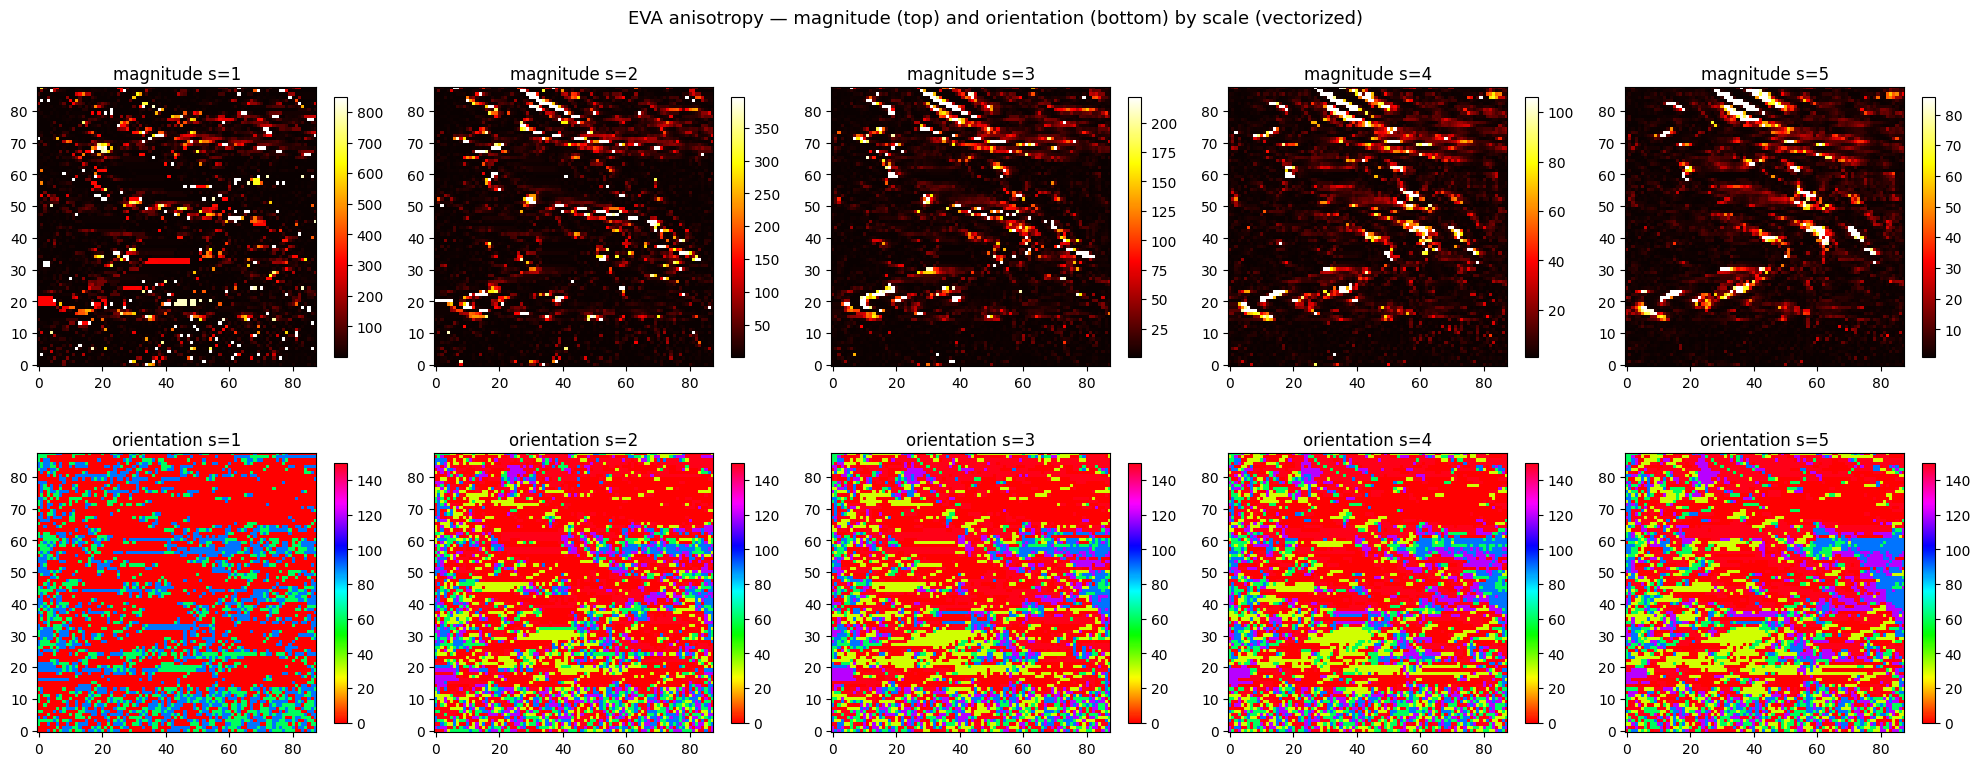

In [30]:
fig, axes = plt.subplots(2, 5, figsize=(20, 8))

for s_idx, s in enumerate(scales):
    # anisotropy magnitude
    arr_mag = anis_mag[:, :, s_idx]
    vmin, vmax = np.nanpercentile(arr_mag[arr_mag != 0], [2, 98])
    im = axes[0, s_idx].imshow(arr_mag, cmap='hot', origin='lower',
                                vmin=vmin, vmax=vmax)
    plt.colorbar(im, ax=axes[0, s_idx], shrink=0.7)
    axes[0, s_idx].set_title(f'magnitude s={s}')

    # anisotropy orientation
    arr_phi = anis_phi[:, :, s_idx].copy()
    arr_phi[arr_phi == 360] = np.nan  # mask uncomputed points
    im = axes[1, s_idx].imshow(arr_phi, cmap='hsv', origin='lower',
                                vmin=0, vmax=150)
    plt.colorbar(im, ax=axes[1, s_idx], shrink=0.7)
    axes[1, s_idx].set_title(f'orientation s={s}')

plt.suptitle('EVA anisotropy — magnitude (top) and orientation (bottom) by scale (vectorized)', fontsize=13)
plt.tight_layout()
plt.show()

In [49]:
# basic stats on difference
diff = anis_mag - anis_mag0[s_max:-s_max, s_max:-s_max, :]

print("diff stats:")
print(f" mean: {diff.mean():.4f}")
print(f" std:  {diff.std():.4f}")
print(f" min:  {diff.min():.4f}")
print(f" max:  {diff.max():.4f}")

# is the discrepancy uniform?
for s_idx, s in enumerate(scales):
    d = diff[:,:, s_idx]
    print(f" s={s}: mean={d.mean():.4f}, max={d.max():.4f}, sum_abs={np.abs(d).sum():.1f}")

# spatial concentration?
print(f"\n non-zero diff cells: {(np.abs(diff) > 1e-6).sum()}")
print(f"total cells : {diff.size}")

diff stats:
 mean: -140.1456
 std:  4860.5761
 min:  -366635.6157
 max:  92902.7128
 s=1: mean=-637.6825, max=92902.7128, sum_abs=5475349.1
 s=2: mean=-61.9770, max=13164.4858, sum_abs=569643.9
 s=3: mean=0.8397, max=1890.3614, sum_abs=81909.1
 s=4: mean=-2.0750, max=1107.9567, sum_abs=37483.6
 s=5: mean=0.1668, max=1723.9075, sum_abs=41761.2

 non-zero diff cells: 24216
total cells : 38720


# diagnostic (from z_interior shift mismatch)

for phi in angles_deg:
    phi_rad = np.radians(phi)
    for s in scales:
        di = int(round(s * np.sin(phi_rad)))
        dj = int(round(s * np.cos(phi_rad)))
        fwd_slice = z_grid[pad+di:pad+di+h, pad+dj:pad+dj+w]
        bwd_slice = z_grid[pad-di:pad-di+h, pad-dj:pad-dj+w]
        if fwd_slice.shape != (h, w) or bwd_slice.shape != (h, w):
            print(f"phi={phi}, s={s}, di={di}, dj={dj}, fwd={fwd_slice.shape}, bwd={bwd_slice.shape}")

In [45]:
it, jt = np.meshgrid(np.arange(6), np.arange(4))
print(it)
print(jt)

[[0 1 2 3 4 5]
 [0 1 2 3 4 5]
 [0 1 2 3 4 5]
 [0 1 2 3 4 5]]
[[0 0 0 0 0 0]
 [1 1 1 1 1 1]
 [2 2 2 2 2 2]
 [3 3 3 3 3 3]]


In [33]:
# compare accumulation approaches at a single point and angle
i, j, phi = 44, 44, 0

# loop version - direct from func_var_s
loop_vals = {}
for s in scales:
    loop_vals[s] = func_var_s(z_grid, i + s_max, j + s_max, s, phi)
    print(f"s={s}: loop={loop_vals[s]:.4f}")

# vectorized accumulation at same point
for s_idx, s in enumerate(scales):
    print(f"s={s}: vec={var_accum[i, j, 0, s_idx]:.4f}")

s=1: loop=0.0000
s=2: loop=3122.2757
s=3: loop=12490.0858
s=4: loop=48411.3181
s=5: loop=82974.1114
s=1: vec=6244.5515
s=2: vec=18735.1287
s=3: vec=64548.4241
s=4: vec=103717.6392
s=5: vec=91063.5753


In [36]:
# verify loop version at the same point we checked before
i_test, j_test = 44 + pad, 44 + pad  # absolute grid coords
phi_test = 0

print("func_var_s outputs:")
for s in scales:
    val = func_var_s(z_grid, i_test, j_test, s, phi_test)
    print(f"  s={s}: {val:.4f}")

print("\nvar_accum at interior point (44,44), phi=0:")
for s_idx, s in enumerate(scales):
    print(f"  s={s}: {var_accum[44, 44, 0, s_idx]:.4f}")

# also manually verify one step
phi_rad = np.radians(0)
di = int(round(1 * np.sin(phi_rad)))
dj = int(round(1 * np.cos(phi_rad)))
print(f"\ndi={di}, dj={dj} for phi=0, s=1")
print(f"z_interior[44,44] = {z_interior[44,44]:.4f}")
print(f"z_grid[pad+di, pad+dj+44] = {z_grid[pad+di, pad+dj+44]:.4f}")
print(f"z_grid[pad-di, pad-dj+44] = {z_grid[pad-di, pad-dj+44]:.4f}")

func_var_s outputs:
  s=1: 0.0000
  s=2: 3122.2757
  s=3: 12490.0858
  s=4: 48411.3181
  s=5: 82974.1114

var_accum at interior point (44,44), phi=0:
  s=1: 6244.5515
  s=2: 18735.1287
  s=3: 64548.4241
  s=4: 103717.6392
  s=5: 91063.5753

di=0, dj=1 for phi=0, s=1
z_interior[44,44] = 426.4230
z_grid[pad+di, pad+dj+44] = 170.0400
z_grid[pad-di, pad-dj+44] = 232.5270


In [37]:
print(f"z_interior[44,44]         = {z_interior[44,44]:.4f}")
print(f"z_grid[pad+44, pad+44]    = {z_grid[pad+44, pad+44]:.4f}")  # should match
print(f"z_grid[pad+44, pad+45]    = {z_grid[pad+44, pad+45]:.4f}")  # fwd neighbor phi=0
print(f"z_grid[pad+44, pad+43]    = {z_grid[pad+44, pad+43]:.4f}")  # bwd neighbor phi=0

# and what the shifted slices give at [44,44]
z_fwd = z_grid[pad:nrows-pad, pad+1:ncols-pad+1]
z_bwd = z_grid[pad:nrows-pad, pad-1:ncols-pad-1]
print(f"z_fwd[44,44] = {z_fwd[44,44]:.4f}")  # should match z_grid[pad+44, pad+45]
print(f"z_bwd[44,44] = {z_bwd[44,44]:.4f}")  # should match z_grid[pad+44, pad+43]

z_interior[44,44]         = 426.4230
z_grid[pad+44, pad+44]    = 426.4230
z_grid[pad+44, pad+45]    = 326.4560
z_grid[pad+44, pad+43]    = 476.3800
z_fwd[44,44] = 326.4560
z_bwd[44,44] = 476.3800


In [38]:
# trace func_var_s step by step at this point
i_test, j_test = 44 + pad, 44 + pad
phi_test = 0

print(f"testing at absolute grid coords i={i_test}, j={j_test}")
for t in range(1, 2):
    vt = func_var_t(z_grid, i_test, j_test, t, phi_test)
    vt_back = func_var_t(z_grid, i_test, j_test, t, phi_test + 180)
    print(f"t={t}: func_var_t fwd={vt:.4f}, bwd={vt_back:.4f}")
    
    phi_rad = np.radians(phi_test)
    di = int(round(t * math.sin(phi_rad)))
    dj = int(round(t * math.cos(phi_rad)))
    print(f"  di={di}, dj={dj}")
    print(f"  z[i,j]={z_grid[i_test,j_test]:.4f}")
    print(f"  z[i+di,j+dj]={z_grid[i_test+di,j_test+dj]:.4f}")

testing at absolute grid coords i=49, j=49
t=1: func_var_t fwd=9993.4011, bwd=2495.7018
  di=0, dj=1
  z[i,j]=426.4230
  z[i+di,j+dj]=326.4560


In [39]:
import inspect
print(inspect.getsource(func_var_s))

def func_var_s(z, i, j, s, phi_deg):
    """cumulative avg variance up to separation distance s,
        averaging both forward and symmetrically backward"""
    accumulator = 0.0
    for t in range(1, s):
        v_fwd = func_var_t(z, i, j, t, phi_deg)
        v_bwd = func_var_t(z, i, j, t, phi_deg + 180)
        accumulator += (v_fwd + v_bwd)
    return accumulator / (2 * s)



In [50]:
# find the worst offenders at s=1
diff_s1 = anis_mag[:,:,0] - anis_mag0[pad:-pad, pad:-pad, 0]

# where are the largest differences?
flat_idx = np.argsort(np.abs(diff_s1).ravel())[::-1][:10]
ii, jj = np.unravel_index(flat_idx, (h, w))

print("top 10 disagreements at s=1:")
for i, j in zip(ii, jj):
    print(f"  ({i},{j}): vec={anis_mag[i,j,0]:.4f}, loop={anis_mag0[pad+i, pad+j, 0]:.4f}, diff={diff_s1[i,j]:.4f}")

top 10 disagreements at s=1:
  (9,65): vec=1.1385, loop=366636.7541, diff=-366635.6157
  (83,31): vec=1.0905, loop=249671.5437, diff=-249670.4533
  (81,36): vec=805.7463, loop=238730.1618, diff=-237924.4155
  (71,35): vec=6906.2309, loop=239540.1978, diff=-232633.9669
  (80,39): vec=530.8996, loop=204294.8373, diff=-203763.9377
  (83,32): vec=1.8468, loop=200964.9894, diff=-200963.1425
  (10,49): vec=2.1590, loop=187032.5957, diff=-187030.4367
  (85,29): vec=1.8465, loop=184981.3995, diff=-184979.5530
  (9,69): vec=1.0001, loop=184706.8578, diff=-184705.8577
  (7,49): vec=1.9192, loop=181941.5826, diff=-181939.6634


In [52]:
i_test, j_test = 83, 31

print("var_accum at s=1 for all angles:")
for a_idx, phi in enumerate(angles_deg):
    print(f"  phi={phi}: vec={var_accum[i_test, j_test, a_idx, 0]:.4f}")

print("\nloop func_var_s at s=1 for all angles:")
for phi in angles_deg:
    val = func_var_s(z_grid, i_test+pad, j_test+pad, 1, phi)
    print(f"  phi={phi}: loop={val:.4f}")

var_accum at s=1 for all angles:
  phi=0: vec=380408.9198
  phi=30: vec=380408.9198
  phi=60: vec=491189.5591
  phi=90: vec=414824.0631
  phi=120: vec=414824.0631
  phi=150: vec=380408.9198

loop func_var_s at s=1 for all angles:
  phi=0: loop=380408.9198
  phi=30: loop=491165.0261
  phi=60: loop=491189.5591
  phi=90: loop=414824.0631
  phi=120: loop=0.9672
  phi=150: loop=380096.3166


In [53]:
print("di, dj for each angle at s=1:")
for phi in angles_deg:
    phi_rad = np.radians(phi)
    di = int(round(1 * np.sin(phi_rad)))
    dj = int(round(1 * np.cos(phi_rad)))
    print(f"  phi={phi}: di={di}, dj={dj}")

di, dj for each angle at s=1:
  phi=0: di=0, dj=1
  phi=30: di=0, dj=1
  phi=60: di=1, dj=1
  phi=90: di=1, dj=0
  phi=120: di=1, dj=0
  phi=150: di=0, dj=-1


In [54]:
print("func_var_t at point (9+pad, 65+pad) for s=1:")
for phi in angles_deg:
    phi_rad = np.radians(phi)
    di = int(round(1 * np.sin(phi_rad)))
    dj = int(round(1 * np.cos(phi_rad)))
    vt = func_var_t(z_grid, 9+pad, 65+pad, 1, phi)
    vt_back = func_var_t(z_grid, 9+pad, 65+pad, 1, phi+180)
    print(f"  phi={phi}: di={di}, dj={dj}, fwd={vt:.4f}, bwd={vt_back:.4f}")

func_var_t at point (9+pad, 65+pad) for s=1:
  phi=0: di=0, dj=1, fwd=0.0011, bwd=607530.2834
  phi=30: di=0, dj=1, fwd=0.0011, bwd=0.9448
  phi=60: di=1, dj=1, fwd=533629.2127, bwd=0.9448
  phi=90: di=1, dj=0, fwd=410320.0474, bwd=300987.5143
  phi=120: di=1, dj=0, fwd=410320.0474, bwd=669743.0255
  phi=150: di=0, dj=-1, fwd=607530.2834, bwd=669743.0255
